# Toroidal VAE
### Template Space S¹x...xS¹

In [432]:
import os
import sys

mvae_dir = os.path.split(os.getcwd())[0]
if mvae_dir not in sys.path:
    sys.path.append(mvae_dir)

In [433]:
%pwd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [453]:
import torch
import numpy as np
import torch.optim as optim

import lib.dataloaders.synthetic_loader as dataloader
import lib.models.vae.vm_toroidal_vae as model
from lib.models.utils.save_load_models import save_model
import lib.trainer as trainer
import lib.utils as utils

from types import SimpleNamespace



### General set up

In [435]:
# Set random seed for reproducibility
torch.manual_seed(59)
np.random.seed(49)

### Experiment Configurations

In [436]:
loader_config = {
    "dataset_name": "s1_synthetic",
    "batch_size": 128,
    "synthetic_rotation": "random",
    "n_times": 10000,
    "radius": 2.0,
    "n_wiggles": 6,
    "geodesic_distortion_amp": 0.3,
    "embedding_dim": 3,
    "noise_var": 0.0001,
    "geodesic_distortion_func": "wiggles",
    "plot_dataset": True
}

model_config = {
    'data_dim': loader_config["embedding_dim"],
    'latent_dim': 1,
    'sftbeta': 4.5,
    'device': "cpu",
    'encoder_widths': [8, 5],
    'decoder_widths': [100,100,100,100],
}

optimizer_config = {
    "learning_rate": 0.001,
}

trainer_config = {
    'num_epochs': 34,
    'log_interval': 100,
    'recon_loss': "MSE",
    'topo_loss': False,
    'alpha': 1.0,  # Weight for reconstruction loss
    'beta': .1,  # Weight for KL loss
    'gamma': 1.0,  # Weight for topological loss
}

curvature_config = {
    "n_grid_points": 2000,  # to compute curvature
    "manifold_dim": 1,
}

config_dict = {}
config_dict.update(loader_config)
config_dict.update(model_config)
config_dict.update(optimizer_config)
config_dict.update(trainer_config)
config_dict.update(curvature_config)

config = SimpleNamespace(**config_dict)

 ### Dataloader

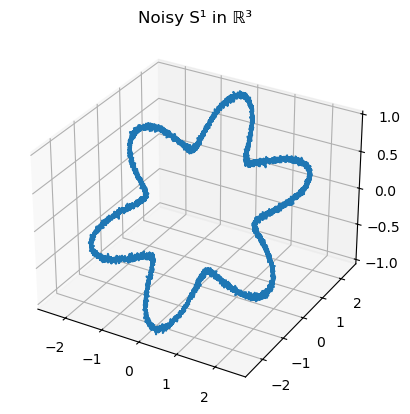

In [437]:
dataloader = dataloader.load_synthetic_ds(config)
train_loader, test_loader = dataloader

### Model

In [438]:
model = model.VMToroidalVAE(config)

### Optimizer

In [439]:
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)

### Train and evaluate model

In [440]:
history = trainer.MVAETrainer(model, dataloader, optimizer, config).train()

Trainer successfully initialized.
Training the vm_toroidalVAE model.
Starting epoch 1/34
Epoch 1/34, Train Loss: 4.2128, Test Loss: 4.1938
--------------------------------------------------
Starting epoch 2/34
Epoch 2/34, Train Loss: 3.8958, Test Loss: 3.6742
--------------------------------------------------
Starting epoch 3/34
Epoch 3/34, Train Loss: 3.5517, Test Loss: 3.4148
--------------------------------------------------
Starting epoch 4/34
Epoch 4/34, Train Loss: 3.2986, Test Loss: 3.3039
--------------------------------------------------
Starting epoch 5/34
Epoch 5/34, Train Loss: 3.0040, Test Loss: 2.9855
--------------------------------------------------
Starting epoch 6/34
Epoch 6/34, Train Loss: 2.8312, Test Loss: 2.8626
--------------------------------------------------
Starting epoch 7/34
Epoch 7/34, Train Loss: 2.6820, Test Loss: 2.7362
--------------------------------------------------
Starting epoch 8/34
Epoch 8/34, Train Loss: 2.4395, Test Loss: 2.1955
--------------

### Visualization 

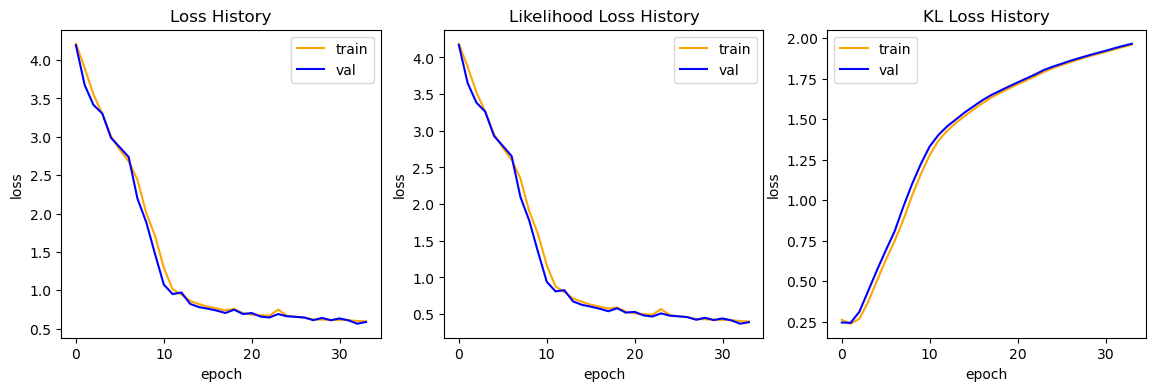

In [441]:
utils.show_training_history(history)

#### Plot latent space

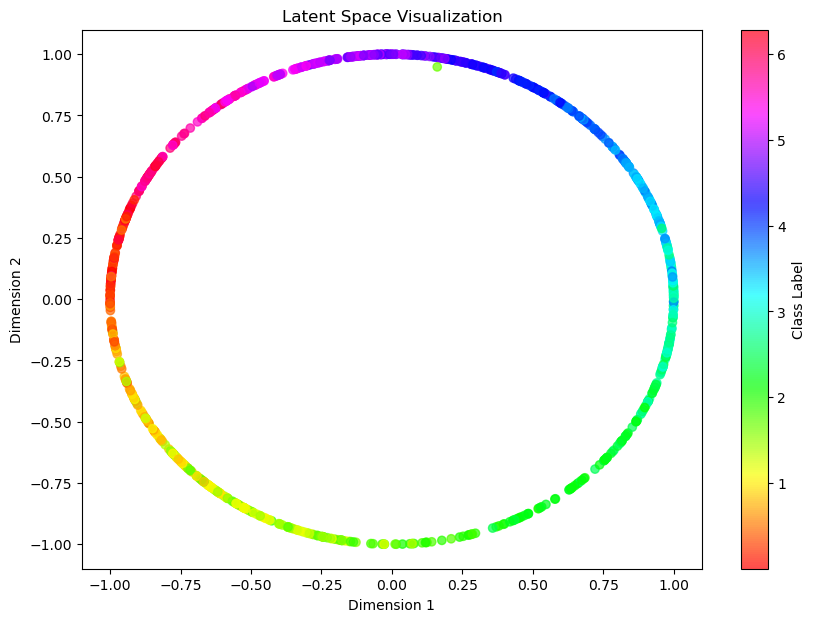

In [442]:
utils.plot_euclidean_latent_space(model, test_loader, n_samples=10000)

### Plot reconstructed manifold

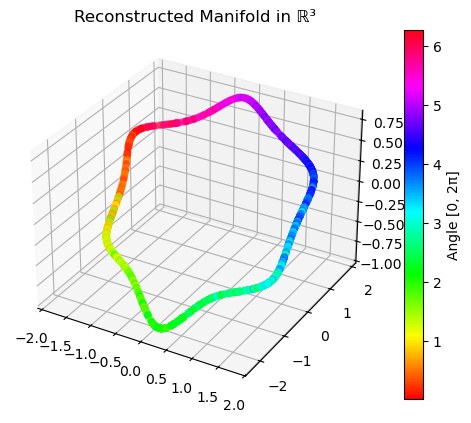

In [443]:
utils.plot_recon_manifold(model, test_loader, n_samples=1000)

In [444]:
breakpoint(quit)

AttributeError: 'ZMQExitAutocall' object has no attribute 'f_back'

#### Compute curvature error

Computing learned curvature...
Computation time: 21.837 s
Computing true curvature for synthetic data...
Computation time: 16.275 s
Computing curvature error for synthetic data...


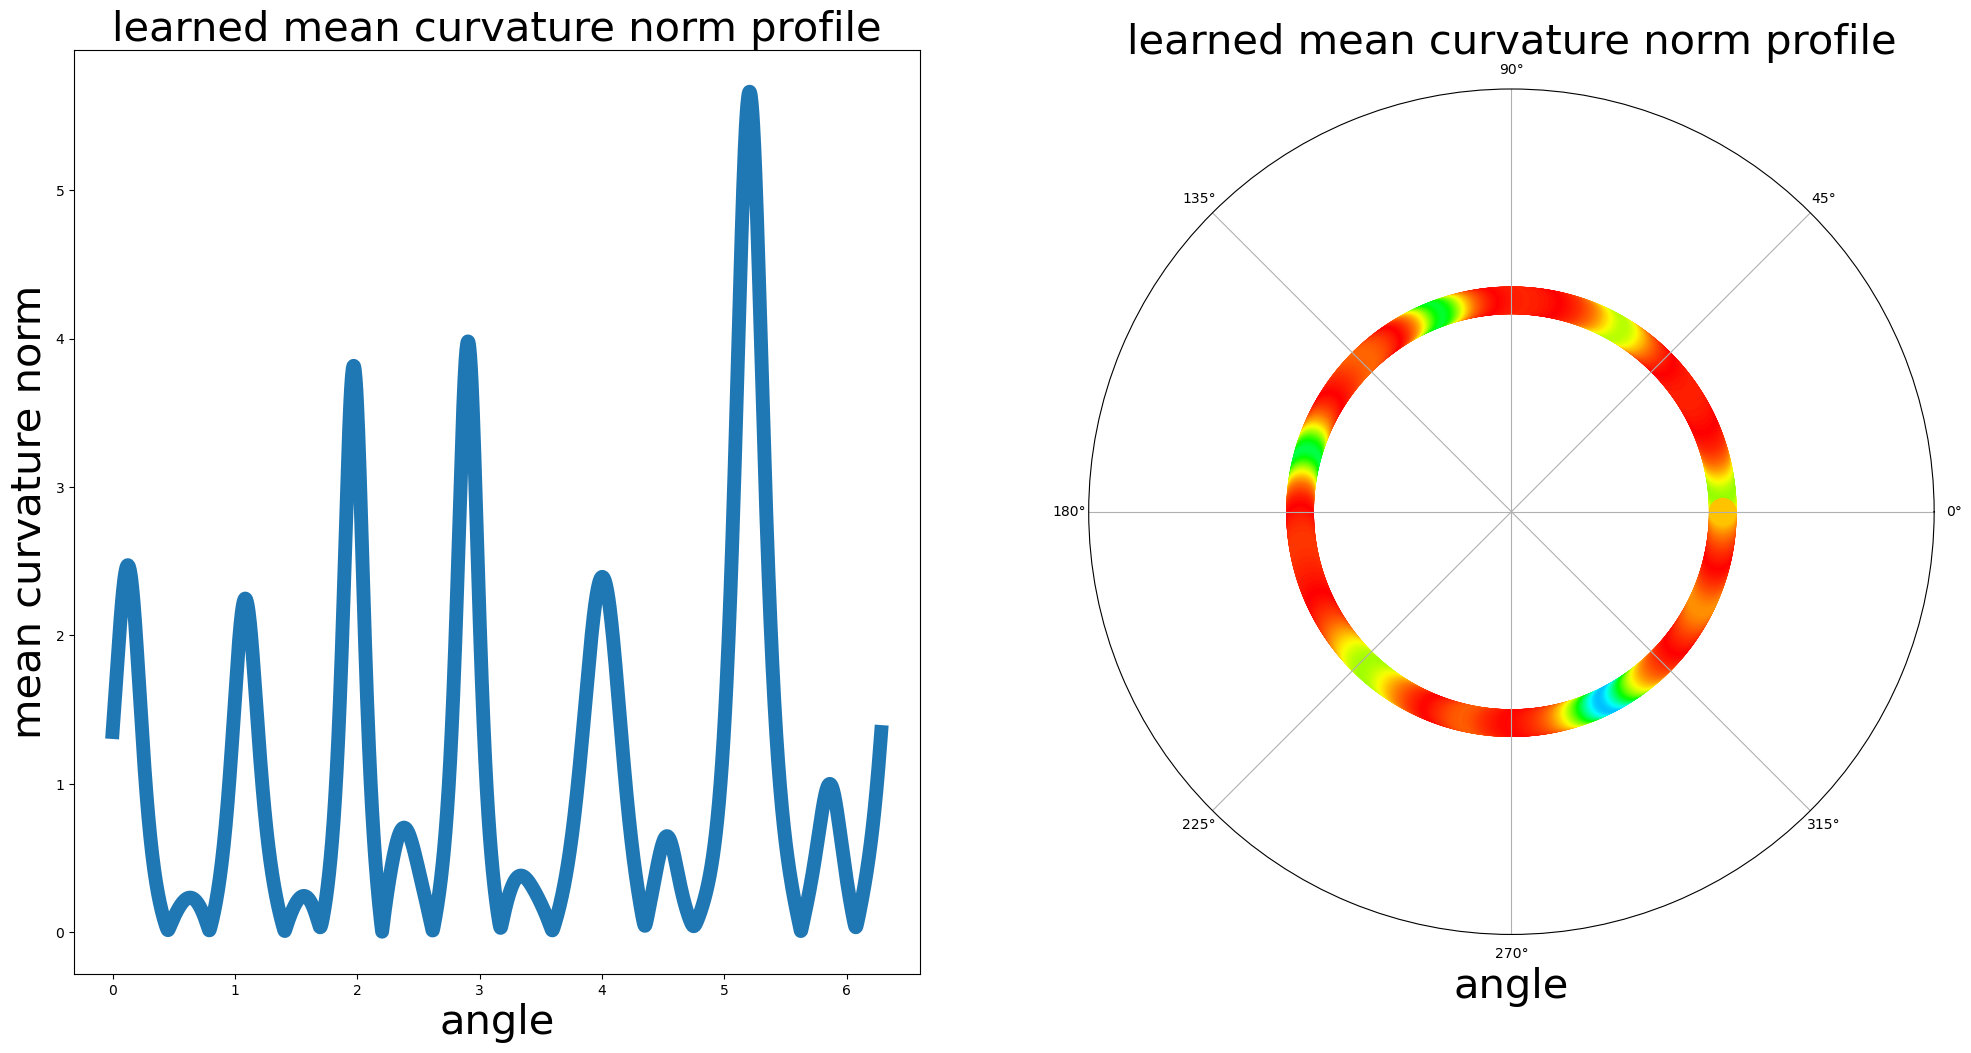

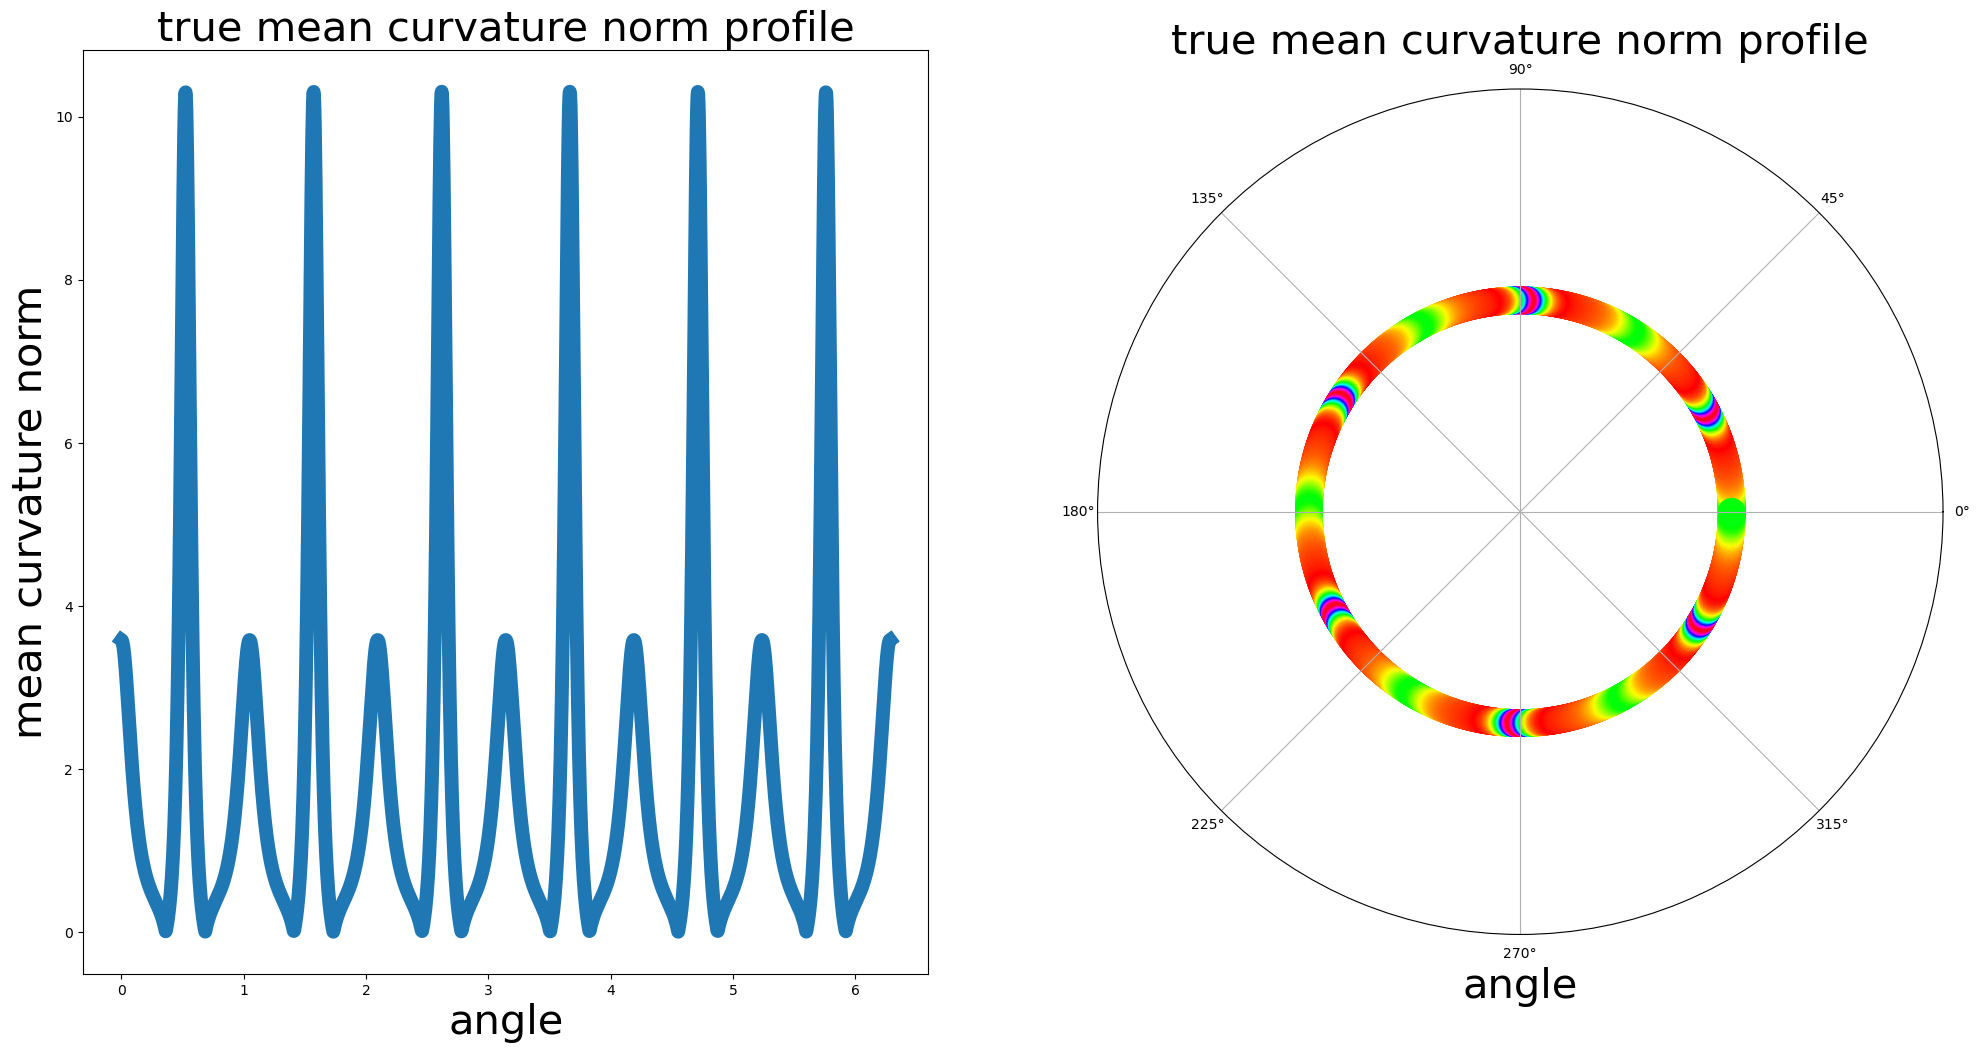

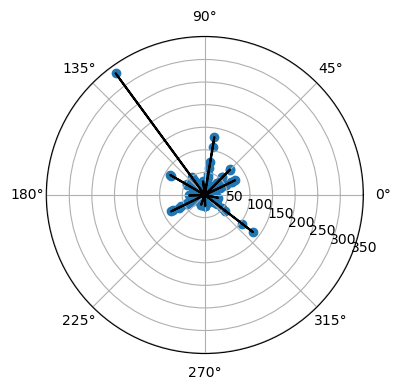

In [445]:
all_data = []
all_labels = []

for data, labels in test_loader:
    all_data.append(data)
    all_labels.append(labels)

all_data = torch.cat(all_data)
all_labels = torch.cat(all_labels)

utils.curvature_compute_plot(config, all_data, all_labels, model)

### Save trained models

In [454]:
save_model(model, config)

AttributeError: module 'lib.models.vae.vm_toroidal_vae' has no attribute 'posterior_type'

### Load pretrained models

In [ ]:
#model = modelutils.load_model("gaussian_1740054584")
#model = model